In [7]:
%load_ext autoreload
%autoreload 2

import random
import sys
from pathlib import Path
from types import SimpleNamespace

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Continuous scripts use float32 modules.
torch.set_default_dtype(torch.float32)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def find_root(current_path, marker="setup.py"):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / marker).exists():
            return parent
    return current_path


PROJECT_ROOT = find_root(Path.cwd())
SRC_DIR = PROJECT_ROOT / "src"
DATASETS_DIR = PROJECT_ROOT / "data" / "datasets"
RESULTS_DIR = PROJECT_ROOT / "data" / "results"
ASSETS_DIR = PROJECT_ROOT / "experiments" / "shared" / "assets"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from rl_methods.sbeed.features import (
    ContinuousNeuralRhoParam,
    ContinuousNeuralValueParam,
    ContinuousStateActionMLPModule,
    ContinuousStateMLPValueModule,
    RFFGaussianPolicyParam,
)
from rl_methods.sbeed.solvers import ContinuousSBEED

print(DEVICE)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
cuda


In [8]:
def evaluate_continuous_policy(
    solver,
    env_id=None,
    env=None,
    episodes=5,
    deterministic=True,
    seed=SEED,
    render=False,
):
    close_env = False
    if env is None:
        env = gym.make(env_id, render_mode="human" if render else None)
        close_env = True

    returns = []

    for ep in range(episodes):
        reset_result = env.reset(seed=seed + ep)
        obs = reset_result[0] if isinstance(reset_result, tuple) else reset_result
        done = False
        ep_return = 0.0
        steps = 0

        while not done:
            action = solver.sample_action(obs, deterministic=deterministic, clip=True)
            step_result = env.step(action)

            if len(step_result) == 5:
                obs, reward, terminated, truncated, info = step_result
                done = terminated or truncated
            else:
                obs, reward, done, info = step_result

            ep_return += float(reward)
            steps += 1

        returns.append(ep_return)

    if close_env:
        env.close()

    returns = np.asarray(returns, dtype=float)
    print(f"eval_returns={returns}")
    print(f"mean={returns.mean():.3f} std={returns.std():.3f} min={returns.min():.3f} max={returns.max():.3f}")

    return returns

In [19]:
PENDULUM_ENV_ID = "Pendulum-v1" 
pendulum_env = gym.make(PENDULUM_ENV_ID) 
pendulum_obs_dim = int(np.prod(pendulum_env.observation_space.shape)) 
pendulum_action_dim = int(np.prod(pendulum_env.action_space.shape))

pendulum_cfg = SimpleNamespace(
    episodes=340,
    initial_random_steps=20000,
    collect_per_episode=1000,
    updates_per_episode=25,

    batch_size=10000,
    rollout_length=10,
    max_buffer_size=400000,

    hidden_size=64,
    rff_features=100,
    nu=None,
    init_log_std=-1.5,

    gamma=0.995,
    lambda_entropy=0.1,
    eta=0.004,

    lr_value=5e-4,
    lr_rho=5e-4,
    lr_policy=5e-4,
    lr_schedulers={"value": "cosine", "rho": "inverse_time", "policy": "cosine"},
    cosine_t_max=340 * 25,
    cosine_eta_min={"value": 1e-6, "policy": 1e-6},

    fisher_damping=1e-2,
    cg_iters=10,
    tau=1e6,

    seed=SEED,
    device=DEVICE,
    log_every=5,
)

In [20]:
pendulum_value_param = ContinuousNeuralValueParam(
    ContinuousStateMLPValueModule(
        obs_dim=pendulum_obs_dim,
        hidden_sizes=(pendulum_cfg.hidden_size, pendulum_cfg.hidden_size),
        dtype=torch.float32,
    )
)

pendulum_rho_param = ContinuousNeuralRhoParam(
    ContinuousStateActionMLPModule(
        obs_dim=pendulum_obs_dim,
        action_dim=pendulum_action_dim,
        hidden_sizes=(pendulum_cfg.hidden_size, pendulum_cfg.hidden_size),
        output_dim=1,
        dtype=torch.float32,
    )
)

pendulum_policy_param = RFFGaussianPolicyParam(
    obs_dim=pendulum_obs_dim,
    action_dim=pendulum_action_dim,
    num_features=pendulum_cfg.rff_features,
    nu=pendulum_cfg.nu,
    init_log_std=pendulum_cfg.init_log_std,
    dtype=torch.float32,
    seed=pendulum_cfg.seed,
)

In [21]:
pendulum_solver = ContinuousSBEED(
    obs_dim=pendulum_obs_dim,
    action_dim=pendulum_action_dim,
    gamma=pendulum_cfg.gamma,
    value_param=pendulum_value_param,
    rho_param=pendulum_rho_param,
    policy_param=pendulum_policy_param,
    lambda_entropy=pendulum_cfg.lambda_entropy,
    eta=pendulum_cfg.eta,
    lr_value=pendulum_cfg.lr_value,
    lr_rho=pendulum_cfg.lr_rho,
    lr_policy=pendulum_cfg.lr_policy,
    lr_schedulers=pendulum_cfg.lr_schedulers,
    cosine_t_max=pendulum_cfg.cosine_t_max,
    cosine_eta_min=pendulum_cfg.cosine_eta_min,
    batch_size=pendulum_cfg.batch_size,
    rollout_length=pendulum_cfg.rollout_length,
    max_buffer_size=pendulum_cfg.max_buffer_size,
    fisher_damping=pendulum_cfg.fisher_damping,
    cg_iters=pendulum_cfg.cg_iters,
    tau=pendulum_cfg.tau,
    seed=pendulum_cfg.seed,
    device=pendulum_cfg.device,
)

pendulum_result = pendulum_solver.run_env(
    pendulum_env,
    episodes=pendulum_cfg.episodes,
    initial_random_steps=pendulum_cfg.initial_random_steps,
    collect_per_episode=pendulum_cfg.collect_per_episode,
    updates_per_episode=pendulum_cfg.updates_per_episode,
    log_every=pendulum_cfg.log_every,
)

pendulum_returns = pendulum_result["episode_returns"]
pendulum_avg_return = float(np.mean(pendulum_returns[-10:])) if pendulum_returns else float("nan")

print(f"buffer_size={pendulum_result['buffer_size']}")
print(f"recent_avg_return={pendulum_avg_return:.3f}")
print("last_stats:", pendulum_result["last_stats"])


episode=0/500 buffer=5200 objective=2988.727051 primal_mse=2996.883789 dual_mse=2039.165039 avg_return_10=-1129.086
episode=5/500 buffer=6200 objective=2173.282715 primal_mse=2173.640137 dual_mse=89.378586 avg_return_10=-1230.999
episode=10/500 buffer=7200 objective=1659.215576 primal_mse=1659.433350 dual_mse=54.455017 avg_return_10=-1227.896
episode=15/500 buffer=8200 objective=1332.482666 primal_mse=1332.617310 dual_mse=33.653915 avg_return_10=-1198.020
episode=20/500 buffer=9200 objective=1134.824097 primal_mse=1134.933228 dual_mse=27.291632 avg_return_10=-1310.808


ValueError: dataset observations must be finite

eval_returns=[ -891.64758362 -1596.87964649 -1429.40179338 -1594.5228585
 -1518.15862942]
mean=-1406.122 std=264.447 min=-1596.880 max=-891.648


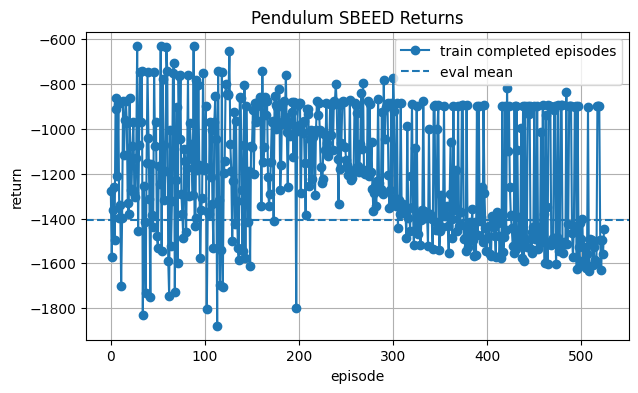

sample_obs: [-0.14995256  0.9886932  -0.12224312]
deterministic_action: [-1.4648844]
value(sample_obs): -50.17710876464844
rho(sample_obs, action): -51.680850982666016


In [ ]:
pendulum_eval_returns = evaluate_continuous_policy(
    pendulum_solver,
    env_id=PENDULUM_ENV_ID,
    episodes=5,
    deterministic=True,
    seed=SEED,
)

plt.figure(figsize=(7, 4))
plt.plot(pendulum_returns, marker="o", label="train completed episodes")
plt.axhline(pendulum_eval_returns.mean(), linestyle="--", label="eval mean")
plt.xlabel("episode")
plt.ylabel("return")
plt.title("Pendulum SBEED Returns")
plt.legend()
plt.grid(True)
plt.show()

sample_obs, _ = pendulum_env.reset(seed=SEED)
sample_action = pendulum_solver.sample_action(sample_obs, deterministic=True)
sample_value = pendulum_solver.value(sample_obs).detach().cpu().item()
sample_rho = pendulum_solver.rho(sample_obs, sample_action).detach().cpu().item()

print("sample_obs:", sample_obs)
print("deterministic_action:", sample_action)
print("value(sample_obs):", sample_value)
print("rho(sample_obs, action):", sample_rho)
